# Part 1 — FCNN From Scratch on UCI Adult

## Objective

Build a three-layer fully connected neural network entirely with NumPy for binary income classification on the UCI Adult Census Income dataset.

The goal is to implement the core components of an FCNN from first principles—parameter initialization, forward propagation, binary cross-entropy, backpropagation, and vanilla SGD—and then investigate how input feature scaling affects gradient magnitudes and optimization behavior.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)

## 1. Dataset and Preprocessing

The UCI Adult Census Income dataset is used for binary classification. The original dataset contains 14 input variables, including numerical and categorical features, with the target indicating whether annual income is `<=50K` or `>50K`.

The predefined training and test splits are preserved. Missing categorical values represented by `?` are replaced using the corresponding mode from the training data. Categorical features are then one-hot encoded, producing 105 input features.

The preprocessing applied to the training data is also used consistently when preparing the test data.

In [4]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

In [5]:
train_df = pd.read_csv("../Data/Adult_census/adult.data",
                       names = columns,
                       skipinitialspace=True)

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
train_df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
train_df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
train_df["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [10]:
(train_df=="?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [11]:
test_df = pd.read_csv("../Data/Adult_census/adult.test",
                      names=columns,
                      skipinitialspace=True,
                      skiprows=1)

In [12]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       16281 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education-num   16281 non-null  int64 
 5   marital-status  16281 non-null  object
 6   occupation      16281 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital-gain    16281 non-null  int64 
 11  capital-loss    16281 non-null  int64 
 12  hours-per-week  16281 non-null  int64 
 13  native-country  16281 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


In [13]:
train_df = train_df.replace("?", np.nan)
test_df = test_df.replace("?", np.nan)

In [14]:
train_df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [ ]:
X = train_df.drop("income",axis=1)
categorical_cols = X.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    mode_value = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_value)
    test_df[col] = test_df[col].fillna(mode_value)

In [16]:
train_df.isna().sum().sum(), test_df.isna().sum().sum()

(np.int64(0), np.int64(0))

In [17]:
X_train = train_df.drop("income",axis=1)
y_train = train_df["income"]

X_test = test_df.drop("income",axis=1)
y_test = test_df["income"]

In [18]:
y_train = y_train.map({
    "<=50K":0,
    ">50K":1
})

y_test = y_test.str.replace(".","").map({
    "<=50K":0,
    ">50K":1
})

In [19]:
y_train.value_counts(), y_test.value_counts()

(income
 0    24720
 1     7841
 Name: count, dtype: int64,
 income
 0    12435
 1     3846
 Name: count, dtype: int64)

In [20]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    dtype=int
)
X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    dtype=int
)

In [21]:
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [22]:
X_train.shape, X_test.shape

((32561, 105), (16281, 105))

In [23]:
X_train = X_train.to_numpy(dtype=np.float64)
X_test = X_test.to_numpy(dtype=np.float64)

y_train = y_train.to_numpy(dtype=np.float64)
y_test = y_test.to_numpy(dtype=np.float64)

In [24]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print(X_train.dtype)
print(y_train.dtype)

X_train: (32561, 105)
y_train: (32561,)
X_test : (16281, 105)
y_test : (16281,)
float64
float64


### Preprocessing Result

After cleaning, encoding, and conversion to NumPy arrays, the network receives 105 numerical input features.

The resulting shapes are:

- Training features: `(32,561, 105)`
- Test features: `(16,281, 105)`
- Training targets: `(32,561,)`
- Test targets: `(16,281,)`

The target is encoded as `0` for `<=50K` and `1` for `>50K`.

## 2. FCNN Architecture and Implementation

The network contains two hidden layers followed by a single sigmoid output:

| Layer | Configuration |
|---|---|
| Input | 105 features |
| Hidden 1 | 64 neurons + ReLU |
| Hidden 2 | 32 neurons + ReLU |
| Output | 1 neuron + Sigmoid |

Weights are initialized using He initialization and biases are initialized to zero. Binary cross-entropy is used as the loss function, and parameters are updated using vanilla stochastic gradient descent.

All neural-network operations below are implemented directly with NumPy rather than a deep-learning framework.

In [25]:
def initialize_parameters(n_input, n_hidden1, n_hidden2, n_output=1):
    W1 = np.random.randn(n_input,n_hidden1)*np.sqrt(2/n_input)
    b1 = np.zeros((1,n_hidden1))

    W2 = np.random.randn(n_hidden1,n_hidden2)*np.sqrt(2/n_hidden1)
    b2 = np.zeros((1,n_hidden2))

    W3 = np.random.randn(n_hidden2, n_output)*np.sqrt(2/n_hidden2)
    b3 = np.zeros((1,n_output))

    return W1, b1, W2, b2, W3, b3

### Activation Functions

ReLU is used in the hidden layers to introduce non-linearity, while the sigmoid activation converts the final output into a probability for the binary classification task.

The sigmoid input is clipped numerically to avoid overflow when evaluating the exponential.

In [26]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

In [27]:
def forward_propagation(X,parameters):
    W1, b1, W2, b2, W3, b3 = parameters

    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)

    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)

    cache = (X, Z1, A1, Z2, A2, Z3, A3)

    return A3, cache

In [28]:
def compute_loss(y, y_pred):
    m = y.shape[0]

    y = y.reshape(-1,1)

    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1- epsilon)

    loss = -(1/m) * np.sum(
        y* np.log(y_pred) + (1-y) * np.log(1-y_pred)
    )

    return loss

In [29]:
def backward_propagation(y, parameters, cache):
    W1, b1, W2, b2, W3, b3 = parameters
    X, Z1, A1, Z2, A2, Z3, A3 = cache

    m = X.shape[0]

    dZ3 = A3 - y.reshape(-1,1)

    dW3 = (1/m) * (A2.T @ dZ3)
    db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)

    dW2 = (1/m) * (A1.T @ dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (1/m) * (X.T @ dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)

    gradients = (dW1, db1, dW2, db2, dW3, db3)

    return gradients

In [30]:
def update_parameters(parameters, gradients, learning_rate):
    W1, b1, W2, b2, W3, b3 = parameters
    dW1, db1, dW2, db2, dW3, db3 = gradients

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    return W1, b1, W2, b2, W3, b3

In [31]:
def train(X, y, iterations, learning_rate):
    n_input = X.shape[1]

    parameters = initialize_parameters(
        n_input=n_input,
        n_hidden1=64,
        n_hidden2=32
    )

    for i in range(iterations):
        y_pred, cache = forward_propagation(X, parameters)

        loss = compute_loss(y, y_pred)

        gradients = backward_propagation(
            y,
            parameters,
            cache
        )

        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss:.4f}")

    return parameters

In [32]:
def train_with_gradients_tracking(X, y, iterations, learning_rate):
    n_input = X.shape[1]

    parameters = initialize_parameters(
        n_input=n_input,
        n_hidden1=64,
        n_hidden2=32
    )

    gradient_history = {
        "dW1": [],
        "dW2": [],
        "dW3": []
    }

    loss_history = []

    for i in range(iterations):

        y_pred, cache = forward_propagation(X, parameters)

        loss = compute_loss(y, y_pred)

        gradients = backward_propagation(
            y,
            parameters,
            cache
        )

        dW1, db1, dW2, db2, dW3, db3 = gradients

        gradient_history["dW1"].append(np.linalg.norm(dW1))
        gradient_history["dW2"].append(np.linalg.norm(dW2))
        gradient_history["dW3"].append(np.linalg.norm(dW3))
        
        loss_history.append(loss)

        parameters = update_parameters(
            parameters,
            gradients,
            learning_rate
        )

        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss:.4f}")

    return parameters, loss_history, gradient_history

### Training and Gradient Tracking

The training loop performs the complete optimization cycle:

1. Forward propagation
2. Binary cross-entropy loss computation
3. Manual backpropagation
4. Gradient-norm recording
5. Parameter update using vanilla SGD

For the scaling experiment, the L2 norms of `dW1`, `dW2`, and `dW3` are recorded at every iteration. This allows the effect of feature scaling on gradient magnitudes to be examined directly.

## 3. Initialization Sanity Check

Before training, the forward pass is checked for correct tensor shapes and a finite binary cross-entropy loss.

The very wide initial prediction range reflects the interaction between the raw feature scales and the randomly initialized network. This provides motivation for the later experiment comparing raw and MinMax-scaled inputs.

In [33]:
parameters = initialize_parameters(
    n_input = X_train.shape[1],
    n_hidden1=64,
    n_hidden2=32
)

for name, param in zip(
    ["W1","b1","W2","b2","W3","b3"],
    parameters
):
    print(name, param.shape)

W1 (105, 64)
b1 (1, 64)
W2 (64, 32)
b2 (1, 32)
W3 (32, 1)
b3 (1, 1)


In [34]:
y_pred, cache = forward_propagation(X_train, parameters)

print(y_pred.shape)
print(y_pred.min(), y_pred.max())

(32561, 1)
7.124576406741285e-218 1.0


In [35]:
loss = compute_loss(y_train, y_pred)

print(loss)

4.299369115350708


## 4. Experiment A — Raw Features

The first experiment trains the FCNN directly on the preprocessed numerical features without additional feature scaling.

The model is trained for 5,000 iterations with a learning rate of `0.001`. First-layer gradient norms are tracked alongside the training loss so that the optimization behavior can be examined after training.

In [37]:
raw_parameters, raw_loss_history, raw_gradient_history = train_with_gradients_tracking(
    X_train,
    y_train,
    iterations=5000,
    learning_rate=0.001
    )

Iteration 0: Loss = 14.0912
Iteration 100: Loss = 0.6855
Iteration 200: Loss = 0.6792
Iteration 300: Loss = 0.6732
Iteration 400: Loss = 0.6676
Iteration 500: Loss = 0.6622
Iteration 600: Loss = 0.6570
Iteration 700: Loss = 0.6521
Iteration 800: Loss = 0.6474
Iteration 900: Loss = 0.6430
Iteration 1000: Loss = 0.6388
Iteration 1100: Loss = 0.6348
Iteration 1200: Loss = 0.6309
Iteration 1300: Loss = 0.6273
Iteration 1400: Loss = 0.6238
Iteration 1500: Loss = 0.6205
Iteration 1600: Loss = 0.6174
Iteration 1700: Loss = 0.6144
Iteration 1800: Loss = 0.6115
Iteration 1900: Loss = 0.6088
Iteration 2000: Loss = 0.6062
Iteration 2100: Loss = 0.6037
Iteration 2200: Loss = 0.6014
Iteration 2300: Loss = 0.5991
Iteration 2400: Loss = 0.5970
Iteration 2500: Loss = 0.5949
Iteration 2600: Loss = 0.5930
Iteration 2700: Loss = 0.5911
Iteration 2800: Loss = 0.5894
Iteration 2900: Loss = 0.5877
Iteration 3000: Loss = 0.5860
Iteration 3100: Loss = 0.5845
Iteration 3200: Loss = 0.5830
Iteration 3300: Loss 

In [38]:
y_test_pred, _ = forward_propagation(X_test, raw_parameters)

y_test_pred_class = (y_test_pred >=0.5).astype(int)

accuracy = np.mean(
    y_test_pred_class == y_test.reshape(-1,1)
)

print(f"Test Accuracy: {accuracy * 100:.2f}")

Test Accuracy: 76.61


In [39]:
y_train_pred,_ = forward_propagation(X_train, raw_parameters)

y_train_pred_class = (y_train_pred >= 0.5).astype(int)

train_accuracy = np.mean(
    y_train_pred_class == y_train.reshape(-1,1)
)

print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 76.09%
Test Accuracy: 76.61%


### Raw-Feature Result

The raw-feature model achieves **76.61% test accuracy** after 5,000 iterations.

However, accuracy must be interpreted in the context of the imbalanced Adult target. The majority class already represents approximately 76% of the test set, so the accuracy alone does not indicate strong predictive performance.

The more important observation for this experiment is the optimization behavior, particularly the unusually large first-layer gradients produced by the raw feature scales.

## 5. Experiment B — MinMax Feature Scaling

To investigate the effect of feature magnitude on optimization, the same training data is transformed using MinMax scaling.

The minimum and maximum values are calculated from the training set only. These same values are then used to transform the test set, preventing information from the test set from influencing the preprocessing.

In [40]:
def min_max_scale(X_train, X_test):
    X_min = X_train.min(axis=0)
    X_max = X_train.max(axis=0)

    denominator = X_max - X_min

    denominator[denominator == 0] = 1

    X_train_scaled = (X_train - X_min) / denominator
    X_test_scaled = (X_test - X_min) / denominator

    return X_train_scaled, X_test_scaled

In [41]:
X_train_scaled, X_test_scaled = min_max_scale(X_train, X_test)

print(X_train_scaled.min())
print(X_train_scaled.max())
print(X_test_scaled.min())
print(X_test_scaled.max())

0.0
1.0
0.0
1.0038677822903792


The test-set maximum can slightly exceed `1` because the test set is transformed using the training-set minimum and maximum. A test observation lying outside the training range can therefore produce a value outside `[0, 1]`. This is expected and is preferable to fitting the scaler separately on the test set.

In [42]:
print("Raw feature ranges:")
print(X_train.min(axis=0))
print(X_train.max(axis=0))

print("\nScaled feature ranges:")
print(X_train_scaled.min(axis=0))
print(X_train_scaled.max(axis=0))

Raw feature ranges:
[1.7000e+01 1.2285e+04 1.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+

In [43]:
scaled_parameters, scaled_loss_history, scaled_gradient_history = train_with_gradients_tracking(
    X_train_scaled,
    y_train,
    iterations=5000,
    learning_rate=0.001
)

Iteration 0: Loss = 0.6931
Iteration 100: Loss = 0.6584
Iteration 200: Loss = 0.6314
Iteration 300: Loss = 0.6095
Iteration 400: Loss = 0.5918
Iteration 500: Loss = 0.5774
Iteration 600: Loss = 0.5658
Iteration 700: Loss = 0.5563
Iteration 800: Loss = 0.5484
Iteration 900: Loss = 0.5416
Iteration 1000: Loss = 0.5357
Iteration 1100: Loss = 0.5305
Iteration 1200: Loss = 0.5258
Iteration 1300: Loss = 0.5215
Iteration 1400: Loss = 0.5176
Iteration 1500: Loss = 0.5139
Iteration 1600: Loss = 0.5104
Iteration 1700: Loss = 0.5072
Iteration 1800: Loss = 0.5040
Iteration 1900: Loss = 0.5011
Iteration 2000: Loss = 0.4982
Iteration 2100: Loss = 0.4954
Iteration 2200: Loss = 0.4928
Iteration 2300: Loss = 0.4903
Iteration 2400: Loss = 0.4878
Iteration 2500: Loss = 0.4855
Iteration 2600: Loss = 0.4832
Iteration 2700: Loss = 0.4811
Iteration 2800: Loss = 0.4790
Iteration 2900: Loss = 0.4769
Iteration 3000: Loss = 0.4750
Iteration 3100: Loss = 0.4731
Iteration 3200: Loss = 0.4712
Iteration 3300: Loss =

### Scaled-Feature Training

The same FCNN architecture, learning rate, and training duration are used with the MinMax-scaled features.

The goal is not to optimize for higher accuracy, but to compare how input scaling changes the loss trajectory and gradient magnitudes.

In [44]:
y_test_pred_scaled, _ = forward_propagation(
    X_test_scaled,
    scaled_parameters
)

y_test_pred_class_scaled = (
    y_test_pred_scaled >= 0.5
).astype(int)

scaled_accuracy = np.mean(
    y_test_pred_class_scaled == y_test.reshape(-1,1)
)

print(f"Scaled Test Accuracy: {scaled_accuracy * 100:.2f}%")

Scaled Test Accuracy: 76.37%


In [45]:
y_train_pred_scaled, _ = forward_propagation(
    X_train_scaled,
    scaled_parameters
)

y_train_pred_class_scaled = (
    y_train_pred_scaled >= 0.5
).astype(int)

scaled_train_accuracy = np.mean(
    y_train_pred_class_scaled == y_train.reshape(-1, 1)
)

print(f"Scaled Train Accuracy: {scaled_train_accuracy * 100:.2f}%")

Scaled Train Accuracy: 75.91%


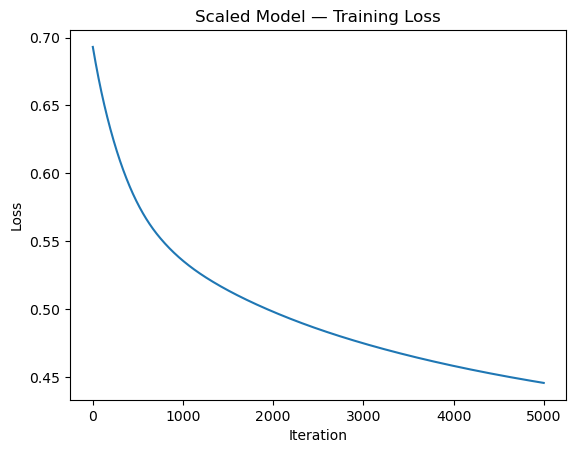

In [46]:
plt.plot(scaled_loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Scaled Model — Training Loss")
plt.show()

## 6. Gradient and Optimization Analysis

The recorded gradient histories allow the optimization behavior of the raw and scaled models to be compared directly.

For the first layer,

\[
dW_1 = \frac{1}{m}X^T dZ_1
\]

so the scale of the input matrix `X` directly affects the magnitude of the first-layer gradients.

The raw Adult features have very different numerical ranges. In particular, features such as `capital-gain` can be much larger than features such as age or hours-per-week. This can produce very large initial gradients in the first layer.

In [47]:
print("Raw initial gradient norms:")
print("dW1:", raw_gradient_history["dW1"][0])
print("dW2:", raw_gradient_history["dW2"][0])
print("dW3:", raw_gradient_history["dW3"][0])

print("\nRaw final gradient norms:")
print("dW1:", raw_gradient_history["dW1"][-1])
print("dW2:", raw_gradient_history["dW2"][-1])
print("dW3:", raw_gradient_history["dW3"][-1])

Raw initial gradient norms:
dW1: 126771.93403341662
dW2: 100468.93694687678
dW3: 62661.13359183802

Raw final gradient norms:
dW1: 0.0
dW2: 0.0
dW3: 0.0


In [48]:
print("Initial gradient norms:")
print("dW1:", scaled_gradient_history["dW1"][0])
print("dW2:", scaled_gradient_history["dW2"][0])
print("dW3:", scaled_gradient_history["dW3"][0])

print("\nFinal gradient norms:")
print("dW1:", scaled_gradient_history["dW1"][-1])
print("dW2:", scaled_gradient_history["dW2"][-1])
print("dW3:", scaled_gradient_history["dW3"][-1])

Initial gradient norms:
dW1: 0.3049674069181224
dW2: 0.32282551482508826
dW3: 0.32266893833177523

Final gradient norms:
dW1: 0.07550607400066944
dW2: 0.056797644820069354
dW3: 0.03923048674824224


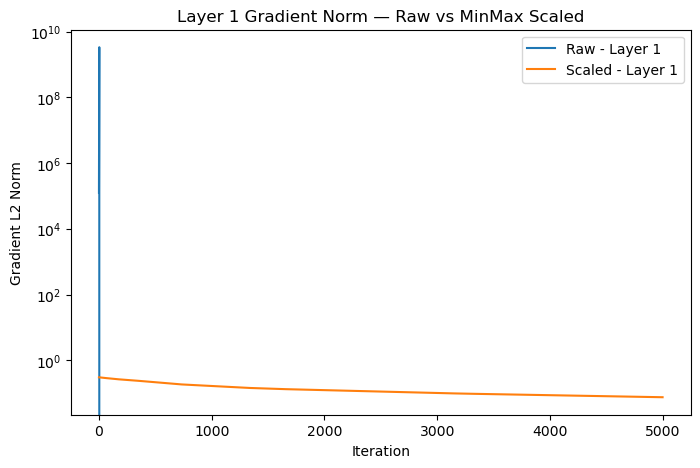

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    raw_gradient_history["dW1"],
    label="Raw - Layer 1"
)

plt.plot(
    scaled_gradient_history["dW1"],
    label="Scaled - Layer 1"
)

plt.xlabel("Iteration")
plt.ylabel("Gradient L2 Norm")
plt.title("Layer 1 Gradient Norm — Raw vs MinMax Scaled")
plt.yscale("log")
plt.legend()
plt.show()

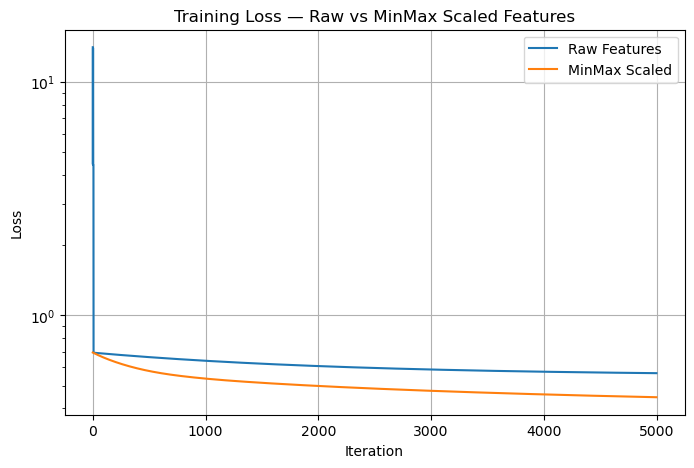

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(raw_loss_history, label="Raw Features")
plt.plot(scaled_loss_history, label="MinMax Scaled")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss — Raw vs MinMax Scaled Features")
plt.yscale("log")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

The raw-feature model begins with dramatically larger first-layer gradients than the MinMax-scaled model. The scaled model also reaches a lower final training loss while retaining non-zero gradients.

This shows that feature scaling substantially changes the numerical behavior of gradient-based optimization. However, the difference in test accuracy is negligible, so the result should not be described as an accuracy improvement.

The experiment therefore demonstrates a distinction between **optimization behavior** and **final classification accuracy**: scaling can make optimization more stable without necessarily producing a higher test accuracy under the same training setup.

In [54]:
print("Raw final loss:", raw_loss_history[-1])
print("Scaled final loss:", scaled_loss_history[-1])

print("Raw initial dW1:", raw_gradient_history["dW1"][0])
print("Raw final dW1:", raw_gradient_history["dW1"][-1])

print("Scaled initial dW1:", scaled_gradient_history["dW1"][0])
print("Scaled final dW1:", scaled_gradient_history["dW1"][-1])

Raw final loss: 0.5652541259161383
Scaled final loss: 0.4458442674589229
Raw initial dW1: 126771.93403341662
Raw final dW1: 0.0
Scaled initial dW1: 0.3049674069181224
Scaled final dW1: 0.07550607400066944


## 7. Final Results

| Metric | Raw Features | MinMax Scaled |
|---|---:|---:|
| Final training loss | 0.565254 | 0.445844 |
| Training accuracy | 76.09% | 75.91% |
| Test accuracy | 76.61% | 76.37% |
| Initial `||dW1||` | 126,771.934 | 0.304967 |
| Final `||dW1||` | 0.0 | 0.075506 |

### Main Finding

MinMax scaling substantially reduced the magnitude of the initial gradients and produced a lower final training loss, but it did not improve test accuracy in this experiment.

The result demonstrates how feature scale can strongly affect the numerical behavior of gradient descent even when the final classification accuracy changes very little.

## 8. Limitations and Interpretation

The Adult target is imbalanced, so accuracy is close to the majority-class baseline and should not be interpreted as strong predictive performance.

The comparison also uses a single training run for each preprocessing condition. The raw and scaled models therefore should not be interpreted as a statistical comparison across multiple random initializations.

The purpose of this experiment is primarily to understand FCNN mechanics and the effect of feature scale on gradient-based optimization rather than to build a state-of-the-art income classifier.